# SILVA Monotone Graph Equilibrium

This lab derives the monotone operator parameterization, its forward-backward
step, the normalized graph operator, and the corresponding SILVA family. It
checks an exact graph-elliptic dataset, trains a compact node field, and tests
node relabeling. The mechanism follows monotone implicit graph networks [47]
and remains inside the canonical `silva_monotone_graph_equilibrium` family.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [4](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [47](https://jseluis.github.io/silva-networks/paper/references/#ref-47). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVAMonotoneGraphEquilibrium,
    SolverConfig,
    make_monotone_chain_dataset,
    normalized_laplacian_field,
)

torch.manual_seed(210)

## 1. Graph Operator and Shape Contract

For node state $Z\in\mathbb R^{N\times d}$, define

$$
G=\frac12\left(I-D^{-1/2}AD^{-1/2}\right),
\qquad GZ\in\mathbb R^{N\times d}.
$$

The factor $1/2$ places the normalized-Laplacian spectrum in $[0,1]$. The
package accepts a directed edge list; bidirectional edges represent an
undirected graph.

In [3]:
data = make_monotone_chain_dataset(nodes=12, channels=1, diffusion=0.6, seed=21)
graph_field = normalized_laplacian_field(data.target, data.edge_index)
equation_error = data.equation_residual().abs().max()

assert data.source.shape == data.target.shape == (12, 1)
assert graph_field.shape == data.target.shape
assert equation_error < 1e-6
print("edges:", data.edge_index.shape[1])
print("maximum graph-equation residual:", float(equation_error))

edges: 22
maximum graph-equation residual: 1.1920928955078125e-07


## 2. Monotone Channel Parameterization

The channel operator is not an unconstrained matrix. It is formed as

$$
W=(1-m)I-CC^T+F-F^T,
\qquad m>0.
$$

Because the skew term vanishes in the symmetric part,

$$
I-\frac{W+W^T}{2}=mI+CC^T\succeq mI.
$$

The smallest eigenvalue is therefore a directly testable certificate. This is
the stability constraint represented by
`SILVAMonotoneGraphTransition.monotonicity_certificate()`.

## 3. Forward-Backward Step as a SILVA Transition

With source $B(X)$ and proximal activation, one operator-splitting step is

$$
Z^{k+1}=\operatorname{prox}_{\alpha f}
\left((1-\alpha)Z^k+\alpha(WGZ^k+B(X))\right).
$$

In SILVA, $B(X)$ is the source branch, $WGZ$ is the graph-local branch, and
the proximal map is the output nonlinearity. Reusing this transition until
convergence produces one implicit graph point rather than an explicit stack.

In [4]:
model = SILVAMonotoneGraphEquilibrium(
    in_dim=1,
    state_dim=6,
    out_dim=1,
    margin=0.15,
    step_size=0.7,
    config=SolverConfig(solver="picard", max_iter=25, tol=1e-6),
)
initial = model(data.source, data.edge_index, return_result=True)

assert initial.output.shape == data.target.shape
assert initial.monotonicity_certificate >= 0.15 - 1e-6
print("certificate:", float(initial.monotonicity_certificate))
print("equilibrium residual:", initial.solver_result.residual)

certificate: 0.15033301711082458
equilibrium residual: 0.005010444670915604


## 4. Tiny Equation-Supervised Task

The target solves

$$
(I+\nu G)u=s.
$$

The loss below teaches the readout and equilibrium transition to approximate
that solution. This is a deterministic small-scale reproduction of the graph
mechanism, not a citation-network benchmark.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-2)
losses = []
for _ in range(12):
    optimizer.zero_grad()
    prediction = model(data.source, data.edge_index)
    loss = torch.nn.functional.mse_loss(prediction, data.target)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

trained = model(data.source, data.edge_index, return_result=True)
print("initial/final task loss:", losses[0], losses[-1])
print("final equilibrium residual:", trained.solver_result.residual)

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


initial/final task loss: 0.5128161311149597 0.09578704833984375
final equilibrium residual: 0.0008736746967770159


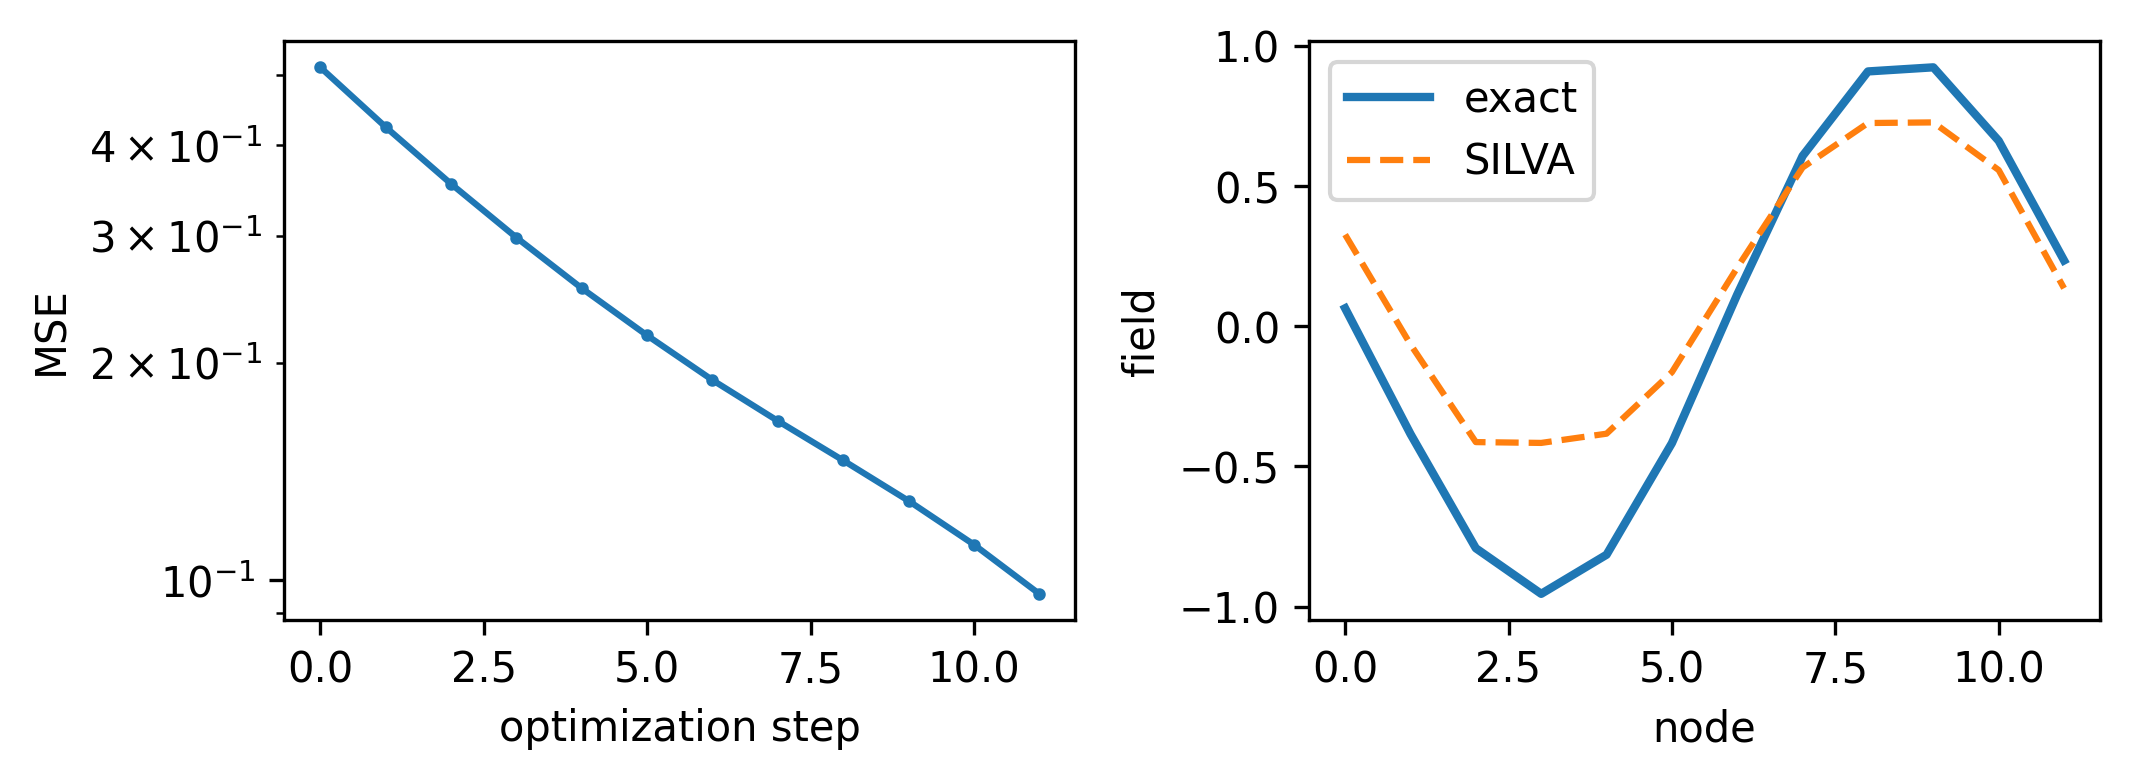

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
axes[0].plot(losses, marker="o", markersize=2)
axes[0].set(xlabel="optimization step", ylabel="MSE", yscale="log")
axes[1].plot(data.target[:, 0], label="exact", linewidth=2)
axes[1].plot(trained.output.detach()[:, 0], "--", label="SILVA")
axes[1].set(xlabel="node", ylabel="field")
axes[1].legend()
figure.tight_layout()
plt.show()

## 5. Node Relabeling

For permutation matrix $P$, a graph equilibrium must satisfy

$$
F(PX,PEP^T)=PF(X,E).
$$

The edge list must be relabeled with the nodes. This is different from
permuting features while leaving graph topology unchanged.

In [7]:
permutation = torch.tensor([7, 1, 10, 3, 5, 9, 0, 11, 2, 8, 4, 6])
inverse = torch.empty_like(permutation)
inverse[permutation] = torch.arange(permutation.numel())
permuted_edges = inverse[data.edge_index]

with torch.no_grad():
    reference = model(data.source, data.edge_index)
    relabeled = model(data.source[permutation], permuted_edges)
equivariance_error = (relabeled - reference[permutation]).abs().max()
assert equivariance_error < 1e-5
print("relabeling error:", float(equivariance_error))

relabeling error: 0.0


## 6. What to Report

Record the graph normalization, directed-edge convention, margin $m$, proximal
map, forward-backward step size, solver, fixed-point residual, and task metric.
The monotonicity certificate diagnoses the parameterization; it does not replace
the numerical residual or downstream accuracy.

## Where to Go Next

| Question | Page |
| --- | --- |
| How is the monotone parameterization derived? | [Advanced Equilibrium Families](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-families/#monotone-graph-equilibrium) |
| Which exact chain equation is checked? | [Advanced Equilibrium Datasets](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-datasets/#monotone-chain) |
| Which graph classes and helpers are public? | [Advanced Equilibria API](https://jseluis.github.io/silva-networks/api/advanced_equilibria/) |
